#Step 1 — Install / Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#Step 2 — Load MNIST Dataset

In [4]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


#Step 3 — Display Some Images

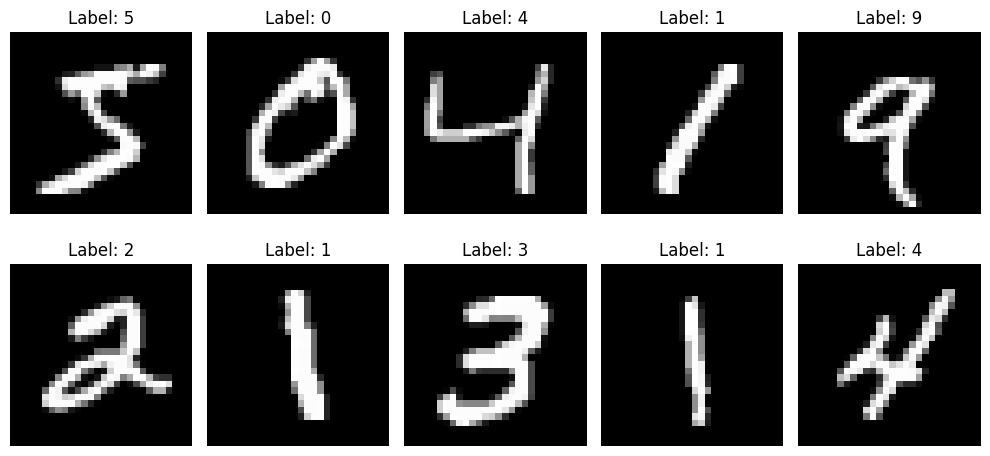

In [5]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Step 4 — Check Class Distribution

In [6]:
unique, counts = np.unique(y_train, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")

Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


#Step 5 — Image Preprocessing

In [7]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("New training shape:", X_train.shape)
print("New testing shape:", X_test.shape)

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)


#Step 6 — Build CNN Model

In [9]:
model = models.Sequential([

    # Convolution Layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Pooling
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Layer
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Second Pooling
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation="relu"),

    # Output Layer
    layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Step 7 — Display Model Architecture

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

#Step 8 — Compile Model

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#Step 9 — Train CNN

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 66ms/step - accuracy: 0.9501 - loss: 0.1613 - val_accuracy: 0.9870 - val_loss: 0.0501
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.9848 - loss: 0.0502 - val_accuracy: 0.9900 - val_loss: 0.0384
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 89s 67ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9892 - val_loss: 0.0394
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - accuracy: 0.9921 - loss: 0.0252 - val_accuracy: 0.9887 - val_loss: 0.0418
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 108s 57ms/step - accuracy: 0.9940 - loss: 0.0189 - val_accuracy: 0.9910 - val_loss: 0.0365
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9952 - loss: 0.0148 - val_accuracy: 0.9923 - val_loss: 0.0333
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.9959 - loss: 0.0126 - val_accuracy: 0.9900 - val_loss: 0.0392
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9969 - loss: 0.0095 -

#Step 10 — Plot Training Accuracy

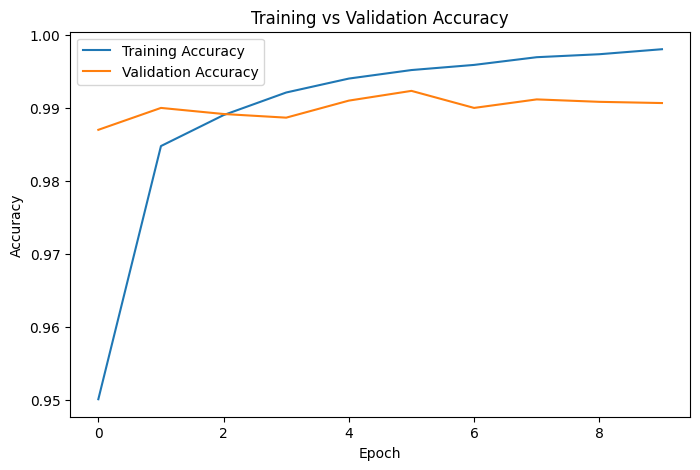

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

#Step 11 — Plot Loss

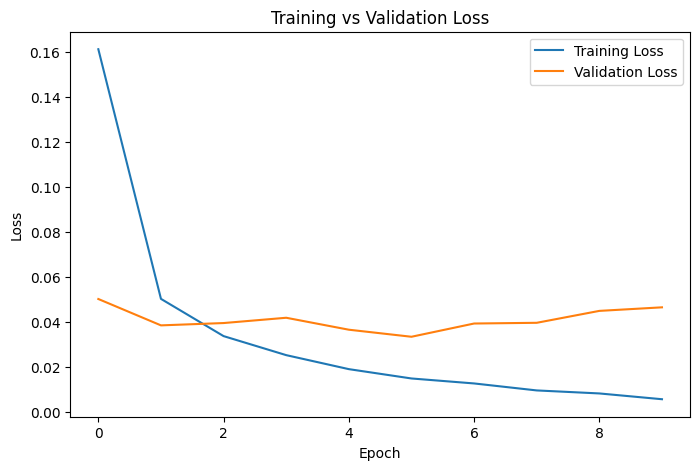

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

#Step 12 — Evaluate on Test Dataset

In [16]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.03152398392558098
Test Accuracy: 0.9921000003814697


#Step 13 — Generate Predictions

In [17]:
y_pred_probability = model.predict(X_test)

y_pred = np.argmax(y_pred_probability, axis=1)

print("Predictions:", y_pred[:20])
print("Actual:", y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Predictions: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 5 4]
Actual: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


#Step 14 — Classification Report

In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



#Step 15 — Confusion Matrix

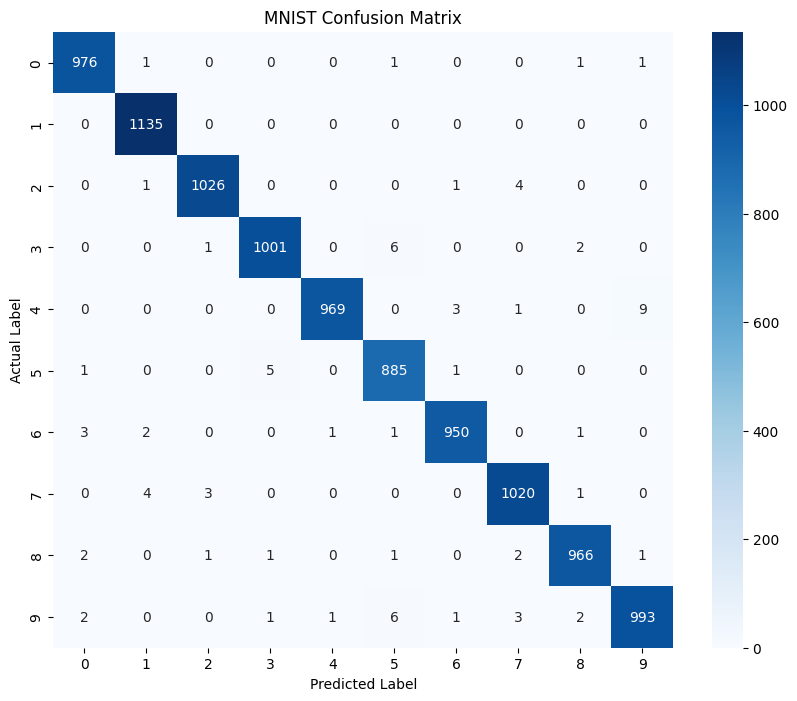

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MNIST Confusion Matrix")

plt.show()

#Step 16 — Test Individual Handwritten Digit

In [20]:
index = 100

image = X_test[index]

prediction = model.predict(
    image.reshape(1, 28, 28, 1)
)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Digit: 6
Actual Digit: 6


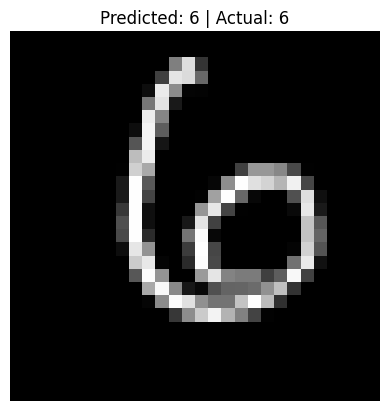

In [21]:
plt.imshow(
    X_test[index].reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Predicted: {predicted_digit} | Actual: {y_test[index]}"
)

plt.axis("off")
plt.show()

#Step 17 — Display Multiple Predictions

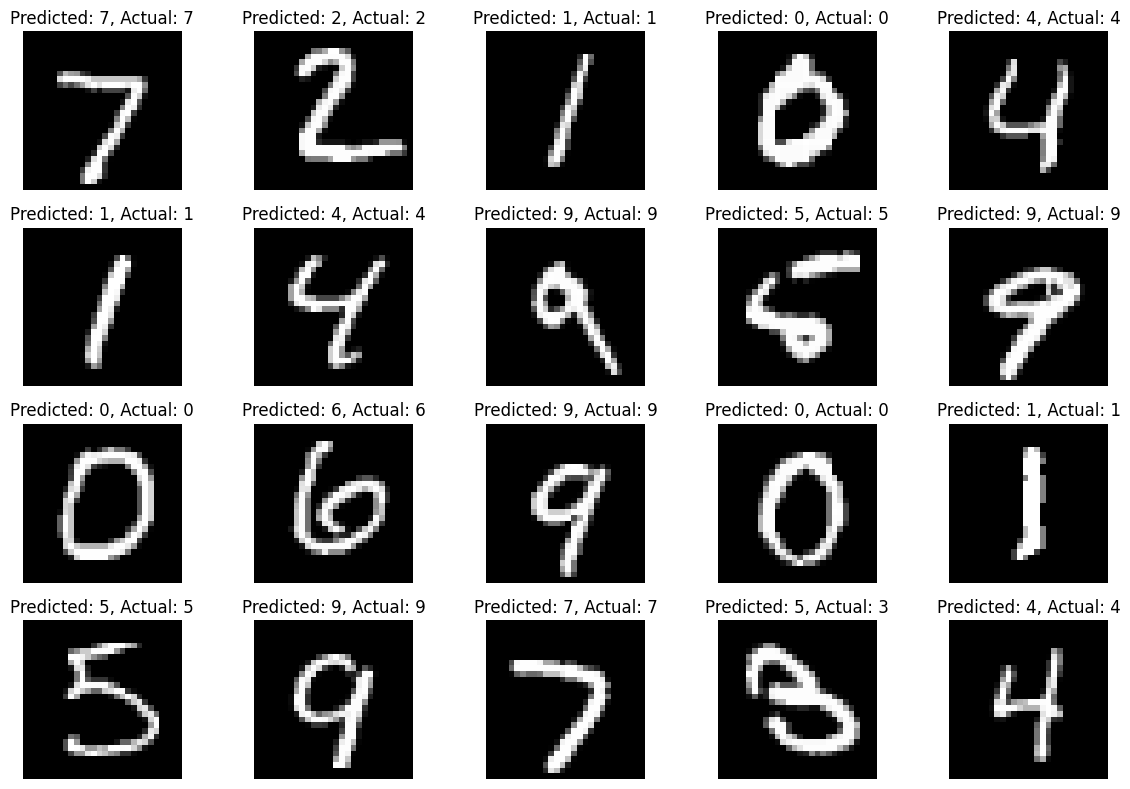

In [23]:
plt.figure(figsize=(12, 8))

for i in range(20):

    prediction = model.predict(
        X_test[i].reshape(1, 28, 28, 1),
        verbose=0
    )

    predicted_digit = np.argmax(prediction)

    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    plt.title(
        f"Predicted: {predicted_digit}, Actual: {y_test[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()